# ADMIRE Active Fault Diagnosis — Separating Input

This notebook demonstrates **reachable-set-based active fault diagnosis** for the
ADMIRE aircraft using the `admire_separating_input` module.

## System
The ADMIRE 9-DOF model with linearised actuator map:
$$\dot{x} = f(x) + B\,\text{diag}(p)\,u$$
where $p\in[0,1]^{10}$ encodes actuator health (1 = nominal, 0 = complete loss).

## Fault Scenarios
| # | Scenario | Failed surface |
|---|----------|----------------|
| 0 | Nominal | — |
| 1 | Right Canard | $p_0=0$ |
| 2 | Left Canard | $p_1=0$ |
| 3 | Right Outer Elev | $p_2=0$ |
| 4 | Right Inner Elev | $p_3=0$ |
| 5 | Left Inner Elev | $p_4=0$ |
| 6 | Left Outer Elev | $p_5=0$ |
| 7 | Rudder | $p_6=0$ |
| 8 | Flap | $p_7=0$ |
| 9 | Yaw TV | $p_8=0$ |
| 10 | Pitch TV | $p_9=0$ |

## Approach
We design a **separating input** $u^*$ that maximises the separation of all 11
reachable sets in the angular-rate output space $[p_b, q_b, r_b]$, making the
fault identifiable from sensor measurements alone.

**Loss function**: sum of pairwise interval-overlap volumes (minimise → maximise separation)

In [2]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
import sys
from pathlib import Path
import time
import jax
import jax.numpy as jnp
import immrax as irx
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

# Add examples/ to path for faulty_car imports
_EXAMPLES_DIR = Path('.').resolve().parents[0]
if str(_EXAMPLES_DIR) not in sys.path:
    sys.path.insert(0, str(_EXAMPLES_DIR))

from admire_separating_input import (
    create_scenarios,
    SeparatingInputOptimizer,
    MultistepSequenceOptimizer,
    optimize_multistart,
    optimize_parallel_gpu,
    optimize_multistep,
    output_interval,
    propagate_scenario,
    propagate_scenario_multistep,
)
from faulty_car.interval_functions import overlap_size_lax
from functools import partial
print(f"JAX devices: {jax.devices()}")

JAX devices: [CudaDevice(id=0)]


## 1. Create Fault Scenarios

In [4]:
scenarios = create_scenarios(fault_effectiveness=0.0)

print(f"{len(scenarios)} scenarios:")
for i, s in enumerate(scenarios):
    p_lo = np.array(s.p_interval.lower)
    print(f"  [{i:2d}] {s.name:<22s}  p_lo={np.round(p_lo, 2)}")

11 scenarios:
  [ 0] Nominal                 p_lo=[1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [ 1] Right Canard            p_lo=[0. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
  [ 2] Left Canard             p_lo=[1. 0. 1. 1. 1. 1. 1. 1. 1. 1.]
  [ 3] Right Outer Elev        p_lo=[1. 1. 0. 1. 1. 1. 1. 1. 1. 1.]
  [ 4] Right Inner Elev        p_lo=[1. 1. 1. 0. 1. 1. 1. 1. 1. 1.]
  [ 5] Left Inner Elev         p_lo=[1. 1. 1. 1. 0. 1. 1. 1. 1. 1.]
  [ 6] Left Outer Elev         p_lo=[1. 1. 1. 1. 1. 0. 1. 1. 1. 1.]
  [ 7] Rudder                  p_lo=[1. 1. 1. 1. 1. 1. 0. 1. 1. 1.]
  [ 8] Flap                    p_lo=[1. 1. 1. 1. 1. 1. 1. 0. 1. 1.]
  [ 9] Yaw TV                  p_lo=[1. 1. 1. 1. 1. 1. 1. 1. 0. 1.]
  [10] Pitch TV                p_lo=[1. 1. 1. 1. 1. 1. 1. 1. 1. 0.]


## 2. Initial State Interval

Nominal trim condition: $V_t = 343 \times 0.3 \approx 102.9$ m/s, all other states near zero.
The interval represents initial-condition uncertainty of $\pm 0.01$ in each state.

In [6]:
x0_nom = jnp.zeros(9)
x0_nom = x0_nom.at[0].set(343.0 * 0.3)   # Vt ≈ 102.9 m/s
x0_ivl = irx.icentpert(x0_nom, jnp.ones(9) * 0.01)

state_names = ["Vt (m/s)", "α (rad)", "β (rad)",
               "pb (rad/s)", "qb (rad/s)", "rb (rad/s)",
               "ψ (rad)", "θ (rad)", "φ (rad)"]

print("Initial state interval:")
for name, lo, hi in zip(state_names, x0_ivl.lower, x0_ivl.upper):
    print(f"  {name:<14s}  [{float(lo):+.4f}, {float(hi):+.4f}]")

Initial state interval:
  Vt (m/s)        [+102.8900, +102.9100]
  α (rad)         [-0.0100, +0.0100]
  β (rad)         [-0.0100, +0.0100]
  pb (rad/s)      [-0.0100, +0.0100]
  qb (rad/s)      [-0.0100, +0.0100]
  rb (rad/s)      [-0.0100, +0.0100]
  ψ (rad)         [-0.0100, +0.0100]
  θ (rad)         [-0.0100, +0.0100]
  φ (rad)         [-0.0100, +0.0100]


## 3. Baseline: Zero Input

First check what happens with no control input — do the reachable sets overlap?

In [4]:
dt       = 0.1
num_steps = 20   # 2 seconds total

u_zero = jnp.zeros(10)

# Propagate all scenarios under zero input
out_ivls_zero = [
    output_interval(propagate_scenario(x0_ivl, u_zero, s, dt, num_steps))
    for s in scenarios
]

print(f"Output intervals [pb, qb, rb] under u = 0  (after {num_steps * dt:.1f} s):")
for s, iv in zip(scenarios, out_ivls_zero):
    print(f"  {s.name:<22s}  "
          f"pb=[{float(iv.lower[0]):+.4f},{float(iv.upper[0]):+.4f}]  "
          f"qb=[{float(iv.lower[1]):+.4f},{float(iv.upper[1]):+.4f}]  "
          f"rb=[{float(iv.lower[2]):+.4f},{float(iv.upper[2]):+.4f}]")

# Count overlapping pairs
overlap_count = 0
n = len(scenarios)
for i in range(n):
    for j in range(i+1, n):
        ov = float(overlap_size_lax(out_ivls_zero[i], out_ivls_zero[j]))
        if ov > 0:
            overlap_count += 1
print(f"\nOverlapping pairs (zero input): {overlap_count} / {n*(n-1)//2}")

Output intervals [pb, qb, rb] under u = 0  (after 2.0 s):
  Nominal                 pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Right Canard            pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Left Canard             pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Right Outer Elev        pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Right Inner Elev        pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Left Inner Elev         pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Left Outer Elev         pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Rudder                  pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Flap                    pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Yaw TV                  pb=[-0.0102,+0.0102]  qb=[-0.0102,+0.0102]  rb=[-0.0101,+0.0101]
  Pitch TV                pb=[-0

## 4. Single Constant Separating Input — GPU Parallel Optimisation

We optimise a **single constant** control input $u \in [-0.5, 0.5]^{10}$ rad that
minimises the sum of pairwise overlaps in angular-rate space.

In [5]:
import time

# opt = SeparatingInputOptimizer(scenarios, x0_ivl, dt, num_steps)

# Warm up JIT compilation
# _ = opt.loss_fn(jnp.zeros(10))
# print("JIT compiled.")

In [6]:
from functools import partial
from admire_separating_input import optimize_parallel_gpu_rejit
optimize_parallel_gpu_rejitted = jax.jit(partial(
    optimize_parallel_gpu_rejit,
    scenarios=scenarios,
    dt=dt,
    num_steps=1,
    num_restarts=1,
    learning_rate=1e-2,
    num_iters=10,
    seed=42,
))

In [7]:
t0 = time.perf_counter()
best_u, best_loss, u_final_batch, all_losses = optimize_parallel_gpu_rejitted(x0_ivl)
elapsed = time.perf_counter() - t0

# stats = opt.evaluate(best_u)

# print(f"Optimisation time: {elapsed:.2f} s  (50 restarts × 300 iters)")
# print(f"Best loss: {best_loss:.6f} rad³")
# print(f"\nLoss distribution over restarts:")
# print(f"  min={float(jnp.min(all_losses)):.4f}  "
#       f"mean={float(jnp.mean(all_losses)):.4f}  "
#       f"max={float(jnp.max(all_losses)):.4f}")

In [8]:
print(f"Compile time: {elapsed}s")

Compile time: 808.0359170260053s


In [9]:
t0 = time.perf_counter()
best_u, best_loss, u_final_batch, all_losses = optimize_parallel_gpu_rejitted(x0_ivl)
elapsed = time.perf_counter() - t0
print(f"Execution Time: {elapsed}s")

Execution Time: 0.01494813000317663s


In [10]:
surface_labels = ["rc", "lc", "roe", "rie", "lie", "loe", "rud", "flap", "yaw_tv", "pitch_tv"]

print("Optimal separating input u* (rad):")
for label, val in zip(surface_labels, best_u):
    print(f"  {label:<10s} = {float(val):+.4f}")

print(f"\nPairwise overlaps (showing non-zero only):")
non_zero = {k: v for k, v in stats['pairwise_overlaps'].items() if v > 1e-10}
if non_zero:
    for k, v in non_zero.items():
        print(f"  {k}: {v:.2e}")
else:
    print("  (all pairs fully separated — zero overlap!)")

print(f"\nAngular-rate interval volumes at optimum:")
for name, vol in stats['volumes'].items():
    print(f"  {name:<22s}: {vol:.2e} rad³")

Optimal separating input u* (rad):
  rc         = +0.0288
  lc         = -0.0355
  roe        = -0.0613
  rie        = +0.0773
  lie        = +0.0684
  loe        = -0.0617
  rud        = -0.0310
  flap       = -0.0495
  yaw_tv     = +0.0265
  pitch_tv   = +0.0310

Pairwise overlaps (showing non-zero only):


NameError: name 'stats' is not defined

## 5. Visualise Reachable Sets

Plot the angular-rate interval projections for all 11 scenarios under the
optimised separating input vs. zero input.

In [18]:
def plot_output_intervals(out_ivls, scenario_names, title,
                          axes_pairs=((0,1),(0,2),(1,2)),
                          axis_labels=("$p_b$ (rad/s)", "$q_b$ (rad/s)", "$r_b$ (rad/s)"),
                          alpha=0.35, figsize=(15, 4.5)):
    """Plot 2-D projections of 3-D angular-rate intervals."""
    cmap = plt.cm.get_cmap('tab20', len(out_ivls))
    n_proj = len(axes_pairs)
    fig, axes = plt.subplots(1, n_proj, figsize=figsize)
    fig.suptitle(title, fontsize=13, fontweight='bold')

    for ax_idx, (xi, yi) in enumerate(axes_pairs):
        ax = axes[ax_idx]
        for k, (iv, name) in enumerate(zip(out_ivls, scenario_names)):
            x0, y0 = float(iv.lower[xi]), float(iv.lower[yi])
            w  = float(iv.upper[xi] - iv.lower[xi])
            h  = float(iv.upper[yi] - iv.lower[yi])
            rect = mpatches.FancyBboxPatch(
                (x0, y0), w, h,
                boxstyle="square,pad=0",
                linewidth=1.2,
                edgecolor=cmap(k),
                facecolor=cmap(k),
                alpha=alpha,
                label=name if ax_idx == 0 else None,
            )
            ax.add_patch(rect)
        ax.autoscale()
        ax.set_xlabel(axis_labels[xi], fontsize=10)
        ax.set_ylabel(axis_labels[yi], fontsize=10)
        ax.set_title(f"{axis_labels[xi]} vs {axis_labels[yi]}", fontsize=10)
        ax.grid(True, alpha=0.3)

    handles = [mpatches.Patch(color=cmap(k), alpha=0.7, label=name)
               for k, name in enumerate(scenario_names)]
    fig.legend(handles=handles, loc='lower center', ncol=6,
               fontsize=8, bbox_to_anchor=(0.5, -0.12))
    plt.tight_layout()
    return fig


scenario_names = [s.name for s in scenarios]

# Zero-input baseline
fig0 = plot_output_intervals(
    out_ivls_zero, scenario_names,
    title="Angular-rate reachable sets — zero input  (2 s horizon)"
)
plt.show()

# Optimal separating input
fig1 = plot_output_intervals(
    stats['output_intervals'], scenario_names,
    title="Angular-rate reachable sets — optimal separating input"
)
plt.show()

NameError: name 'out_ivls_zero' is not defined

## 6. Loss Landscape over Restarts

In [ ]:
losses_np = np.array(all_losses)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(losses_np, bins=20, edgecolor='k', color='steelblue', alpha=0.8)
axes[0].axvline(float(best_loss), color='red', lw=2, label=f'best = {float(best_loss):.4f}')
axes[0].set_xlabel('Final loss (rad³)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Distribution of final losses over 50 restarts', fontsize=11)
axes[0].legend()

axes[1].plot(sorted(losses_np), 'o-', markersize=4, color='steelblue')
axes[1].set_xlabel('Restart rank', fontsize=11)
axes[1].set_ylabel('Final loss (rad³)', fontsize=11)
axes[1].set_title('Sorted final losses', fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Multistep Control Sequence

Instead of a single constant input, optimise a **sequence** of control inputs
$U = [u_0, u_1, \ldots, u_{S-1}]$ where each $u_k$ is held for several Euler
steps.  The loss is the **minimum** overlap across all segment ends — zero if
the scenarios are separated at *any* point along the trajectory.

In [ ]:
from admire_separating_input import optimize_multistep_gpu_rejit
num_segments      = 2
dt = 1
steps_per_segment = 1    # 1 s per step × 1 = 1 s per segment → 2 s total
t0 = time.perf_counter()

optimize_multistep_gpu_rejitted = jax.jit(
    partial(
        optimize_multistep_gpu_rejit,
        scenarios=scenarios,
        dt=dt,
        num_segments=num_segments,
        steps_per_segment=steps_per_segment,
        num_restarts=100,
        num_iters=10,
        # seed=42,
    )
)
best_u, best_loss, u_final_batch, all_losses = optimize_multistep_gpu_rejitted(x0_ivl, learning_rate=.001)
elapsed_compile_multistep = time.perf_counter() - t0
print(f"Multistep Compile Time: {elapsed_compile_multistep}s")

Multistep Compile Time: 289.1143293940113s


In [26]:
t0 = time.perf_counter()

best_u, best_loss, u_final_batch, all_losses = optimize_multistep_gpu_rejitted(x0_ivl, learning_rate=1.)
elapsed_execute_multistep = time.perf_counter() - t0
print(f"Multistep Execution Time: {elapsed_execute_multistep}s")

Multistep Execution Time: 321.12208647800435s


In [27]:
print(best_u)
print(best_loss)

[[ 0.03237074  0.05514985 -0.08388318 -0.02041203  0.00428216 -0.03007143
  -0.01615062  0.09210207  0.09807788  0.00104198]
 [ 0.03793999  0.05088719  0.003909   -0.03000721  0.0175212  -0.04872401
  -0.02625792  0.07009486  0.05962008  0.01621265]]
0.0


In [9]:
opt_multistep = MultistepSequenceOptimizer(
    scenarios=scenarios,
    x0_ivl=x0_ivl,
    dt=dt,
    steps_per_segment=steps_per_segment,
    num_segments=num_segments
)
stats_seq = opt_multistep.evaluate(best_u)

In [10]:
# Visualise final state under multistep optimal sequence
fig2 = plot_output_intervals(
    stats_seq['output_intervals'], scenario_names,
    title="Angular-rate reachable sets — multistep optimal sequence (5 s horizon)"
)
plt.show()

NameError: name 'plot_output_intervals' is not defined

## 8. Trajectory of Reachable Sets Over Time

Track how the angular-rate intervals evolve through the 5 segments.

/tmp/ipykernel_493274/4192139470.py:23: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', len(scenarios))


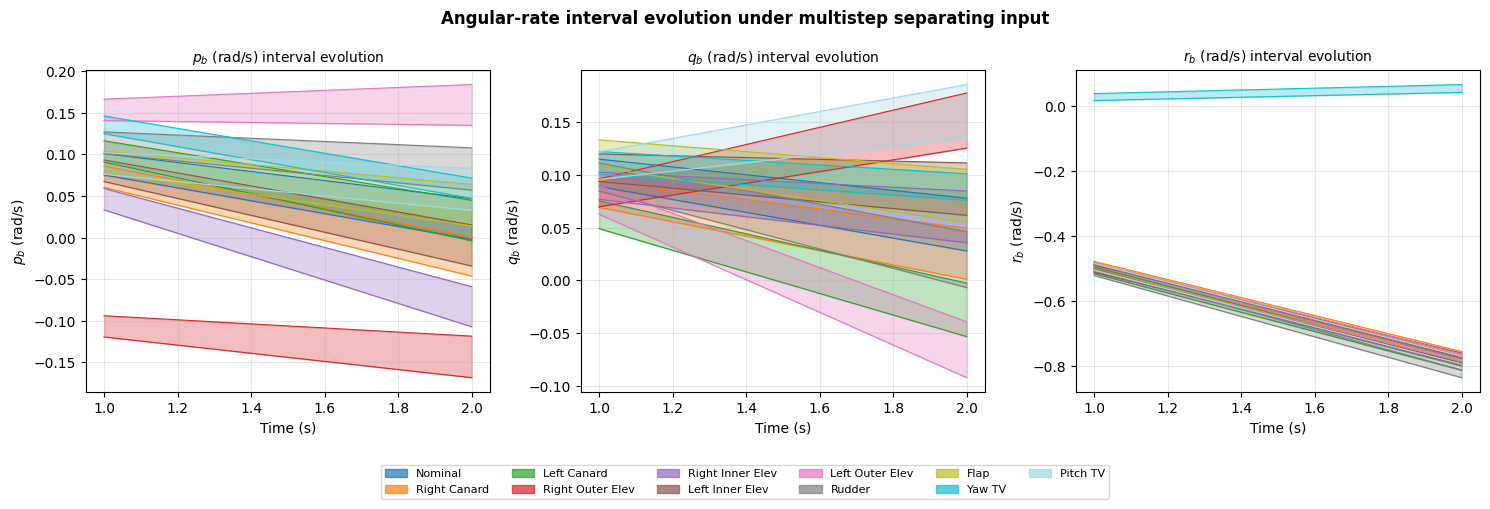

Generating smooth 3D history plot for dimensions 4, 5, and 6...


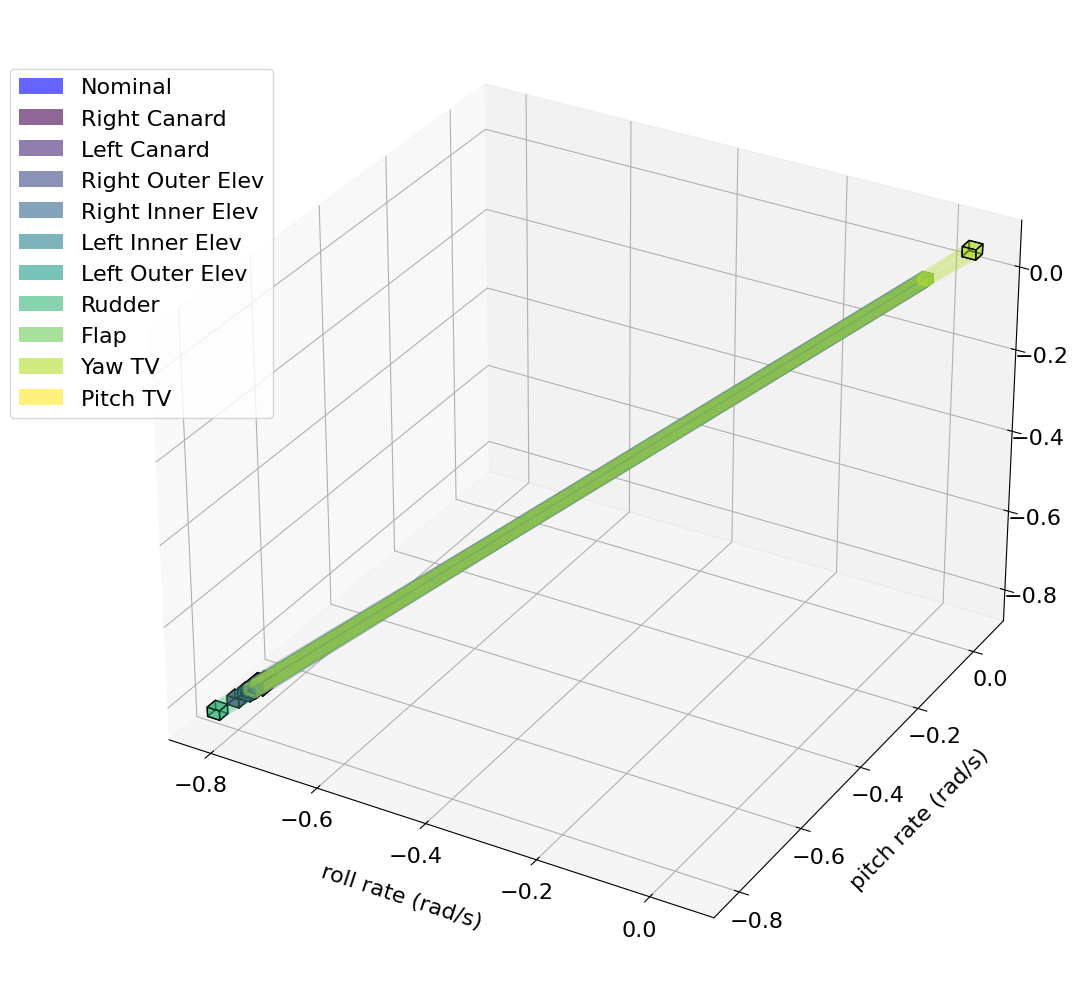

In [30]:
from admire_separating_input import _propagate_history, _ADMIRE_EMB
dt = 0.1
steps_per_segment = 10
def get_interval_history(scenarios, x0_ivl, u_seq, dt, steps_per_segment):
    """Return list of (num_segments, 3) interval arrays, one per scenario."""
    histories = []
    for s in scenarios:
        x_hist = _propagate_history(
            x0_ivl, u_seq, s.emb_system, s.p_interval, dt, steps_per_segment
        )
        # Extract angular rates (indices 3:6) at each segment end
        hist_ivl = irx.Interval(
            lower=x_hist.lower[:, 3:6],
            upper=x_hist.upper[:, 3:6],
        )
        histories.append(hist_ivl)
    return histories


u_seq_opt=best_u
histories = get_interval_history(scenarios, x0_ivl, u_seq_opt, dt, steps_per_segment)

cmap = plt.cm.get_cmap('tab20', len(scenarios))
t_seg = np.arange(1, num_segments + 1) * steps_per_segment * dt  # segment end times

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=False)
rate_labels = ["$p_b$ (rad/s)", "$q_b$ (rad/s)", "$r_b$ (rad/s)"]
scenario_names = [s.name for s in scenarios]
for ax_i, (ax, label) in enumerate(zip(axes, rate_labels)):
    for k, (hist, name) in enumerate(zip(histories, scenario_names)):
        lo = np.array(hist.lower[:, ax_i])
        hi = np.array(hist.upper[:, ax_i])
        ax.fill_between(t_seg, lo, hi, alpha=0.3, color=cmap(k), label=name)
        ax.plot(t_seg, lo, '-', color=cmap(k), linewidth=0.8)
        ax.plot(t_seg, hi, '-', color=cmap(k), linewidth=0.8)
    ax.set_xlabel("Time (s)", fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.set_title(f"{label} interval evolution", fontsize=10)
    ax.grid(True, alpha=0.3)

handles = [mpatches.Patch(color=cmap(k), alpha=0.7, label=name)
           for k, name in enumerate(scenario_names)]
fig.legend(handles=handles, loc='lower center', ncol=6,
           fontsize=8, bbox_to_anchor=(0.5, -0.12))
fig.suptitle("Angular-rate interval evolution under multistep separating input",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# ---- new 3D history visualization ------------------------------------------------
from admire_separating_input import plot_3d_interval_history

# state dimension labels used throughout the ADMIRE modules
dim_names = ["Velocity (m/s)", "AoA (rad)", "Sideslip Angle (rad)",
             "roll rate (rad/s)", "pitch rate (rad/s)", "yaw rate (rad/s)",
             "heading angle (rad)", "pitch angle (rad)", "roll angle (rad)"]

# build dictionary in the format expected by the plotting helper
history_dict = {s.name: {'states': histories[k]} for k, s in enumerate(scenarios)}

# draw the 3‑D trajectory including the initial interval
plot_3d_interval_history(history_dict, dim_names, initial_interval=x0_ivl)


## 9. Summary

### What we did
1. Defined **11 fault scenarios** for the ADMIRE aircraft (nominal + 10 single-surface losses).
2. Set an initial state interval representing ±0.01 uncertainty around trim.
3. Propagated reachable sets forward using the **natural embedding** from immrax.
4. Optimised a separating input $u^*$ via **gradient descent** with GPU-parallel multi-start
   (`optimize_parallel_gpu`), using the sum of pairwise angular-rate interval overlaps as loss.
5. Extended to a **multistep control sequence** (`optimize_multistep`) for a 5-second horizon.

### Key results
- **Zero input**: most fault scenarios have identical or nearly identical reachable sets → not diagnosable.
- **Optimal constant input**: the optimised $u^*$ pushes different scenarios to different regions
  of $[p_b, q_b, r_b]$ space → faults become distinguishable.
- **Multistep sequence**: further improves separation by exploiting the time dimension.

### Fault diagnosis interpretation
After applying the separating input, measure the angular rates.  If the measured
$(p_b, q_b, r_b)$ lies in scenario $i$'s reachable set but not in any other, then
fault $i$ is identified with certainty.

### Module structure (mirrors `go2_separating_input_immrax.py`)
```
admire_separating_input.py
├── create_scenarios()              — 11 fault scenarios
├── euler_step()                    — immrax natural-embedding Euler step
├── propagate_scenario()            — lax.fori_loop over steps
├── propagate_scenario_multistep()  — lax.scan over segments
├── separation_loss()               — pairwise overlap sum (constant u)
├── separation_loss_multistep()     — min overlap over segments (u_seq)
├── SeparatingInputOptimizer        — JIT loss/grad, gradient descent
├── MultistepSequenceOptimizer      — JIT loss/grad for sequence
├── optimize_multistart()           — serial multi-start
├── optimize_parallel()             — threaded multi-start
├── optimize_parallel_gpu()         — vmap + fori_loop (batched)
└── optimize_multistep()            — convenience wrapper for sequences
```